In [15]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## 1st practice

In [28]:
class BaseClass(TypedDict):
    height_m : float
    weight_kg : float
    bmi : float


def calculate_bmi(state: BaseClass) -> BaseClass:
    height_m = state['height_m']
    weight_kg = state['weight_kg']
    state['bmi'] = weight_kg / (height_m ** 2)

    return state

In [29]:
graph = StateGraph(BaseClass)

In [30]:
graph.add_node('calculate_bmi', calculate_bmi)

graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', END)



In [31]:
app = graph.compile()

In [43]:
initial_state = {"height_m" : 50, "weight_kg" : 60}
end_state = app.invoke(initial_state)

print(end_state['bmi'])

0.024


## 2nd practice

In [63]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [60]:
load_dotenv()
llm = ChatGroq(model='llama-3.1-8b-instant')

In [67]:
class OutlineState(TypedDict):
    topic : str
    outline : str
    blog : str

def gen_outline(state : OutlineState) -> OutlineState:
    topic = state['topic']

    prompt = PromptTemplate(
        template="""
            generate outline for given topic: {topic}
        """,
        input_variables=['topic']
    )
    parser = StrOutputParser()
    chain = prompt | llm | parser

    state['outline'] = chain.invoke({'topic': topic})

    return state


def gen_blog(state : OutlineState) -> OutlineState:
    topic = state['topic']
    outline = state['outline']

    prompt = PromptTemplate(
            template="""
                generate blog for given topic and outline.\n
                topic: {topic}\n
                outline: {outline}
            """,
            input_variables=['topic', 'outline']
        )
    parser = StrOutputParser()
    chain = prompt | llm | parser

    state['blog'] = chain.invoke({'topic': topic, 'outline': outline})

    return state


In [68]:
graph_2 = StateGraph(OutlineState)

graph_2.add_node('gen_outline', gen_outline)
graph_2.add_node('gen_blog', gen_blog)

graph_2.add_edge(START, 'gen_outline')
graph_2.add_edge("gen_outline", 'gen_blog')
graph_2.add_edge('gen_blog', END)

workflow = graph_2.compile()

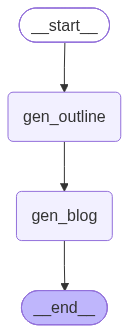

In [71]:
workflow

In [70]:
initial_state = {'topic': 'Mechine learning in Medical Industry'}
final_state = workflow.invoke(initial_state)

print(final_state['blog'])

**Machine Learning in Medical Industry: Revolutionizing Healthcare**

**Introduction**

Machine learning, a subset of artificial intelligence, has been gaining significant attention in recent years for its potential to transform various industries, including the medical industry. The medical industry is one of the most data-intensive and complex sectors, where machine learning can help improve patient outcomes, reduce costs, and enhance the overall quality of care.

**Definition of Machine Learning and its Relevance to the Medical Industry**

Machine learning is a type of artificial intelligence that enables computers to learn from data without being explicitly programmed. It involves training algorithms on large datasets to make predictions or decisions. In the medical industry, machine learning can be applied to various areas, including diagnostics, personalized medicine, and clinical decision support systems.

**The Medical Industry's Need for Machine Learning**

The medical industr

## 3 practice

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
import operator

In [ ]:
class MathState(TypedDict):
    a : int
    b : int
    c : int
    output : str
    equation : str
    discriminant : float

def show_equation(state: MathState):
    equation = f"{state['a']}x^2{state['b']:+}x{state['c']:+}"
    return {'equation' : equation}


def calculate_discriminant(state: MathState):
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = (b**2) - 4*a*c
    return {'discriminant': discriminant}


def no_real_roots(state: MathState):
    output = f"No real output"
    return {'output': output}


def real_roots(state: MathState):
    pos = ((state['b'] * (-1)) + state['discriminant']**0.5) / (2*state['a'])
    neg = ((state['b'] * (-1)) - state['discriminant']**0.5) / (2*state['a'])
    output = f"Two possible values: {round(pos, 3)} & {round(neg, 3)}"
    return {'output': output}


def repeated_roots(state: MathState):
    pos = (state['b'] * (-1)) / (2*state['a'])
    output = f"One possible output: {round(pos, 3)}"
    return {'output': output}


def conditional_step(state: MathState) -> Literal['no_real_roots', 'real_roots', 'repeated_roots']:
    if state['discriminant'] == 0:
        return 'repeated_roots'
    
    elif state['discriminant'] > 0:
        return 'real_roots'
    
    else:
        return 'no_real_roots'

In [37]:
graph = StateGraph(MathState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('no_real_roots', no_real_roots)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant', conditional_step)
graph.add_edge('no_real_roots', END)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)


workflow = graph.compile()

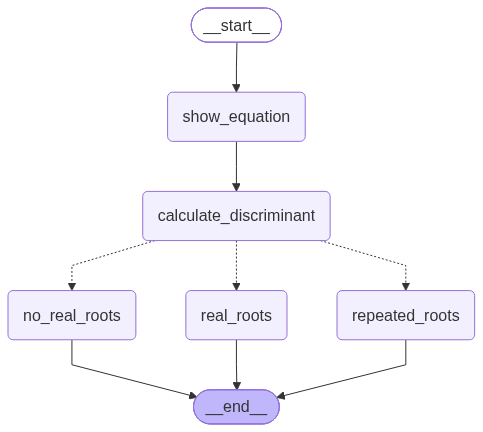

In [38]:
graph.compile()

In [39]:
initial_state = {
    'a': 5,
    'b': -4,
    'c': -2
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 5, 'b': -4, 'c': -2, 'output': 'Two possible values: 1.148 & -0.348', 'equation': '5x^2-4x-2', 'discriminant': 56}


## Implmenting backend for chatbot


In [ ]:
import streamlit as st
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

In [73]:
class MessageState(TypedDict):
    user_input : str
    message : Annotated[list[BaseMessage], add_messages]

In [79]:
load_dotenv()
llm = ChatGroq(model='llama-3.1-8b-instant', temperature=0.2)

def chat_message(state: MessageState):
    all_response = []
    user_input = state['user_input']


    response = llm.invoke(all_response + [HumanMessage(user_input)])

    # print('User:',user_input)
    # print('AI:',response.content)
    
    all_response = all_response + [HumanMessage(user_input)] + [response]
                
    return {'message': all_response}


In [80]:
checkpointer = InMemorySaver()
graph = StateGraph(MessageState)

graph.add_node('chat_message', chat_message)
graph.add_edge(START, 'chat_message')
graph.add_edge('chat_message', END)

chat = graph.compile(checkpointer=checkpointer)


config = {'configurable': {'thread_id': '1'}}
chat.invoke({'user_input': 'hi'}, config=config)


{'user_input': 'hi',
 'message': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='1958efba-6953-46ae-bc65-a33e89a64b2c'),
  AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.006349134, 'completion_tokens_details': None, 'prompt_time': 0.002583539, 'prompt_tokens_details': None, 'queue_time': 0.051332391, 'total_time': 0.008932673}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fb84d-5891-7ce0-8afb-641a9b771d29-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]}

In [87]:
config = {'configurable': {'thread_id': '1'}}
response = chat.invoke({'user_input': 'hi'}, config=config)

print(response['message'][0].content)

hi


# Rag Feature

In [22]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_core.prompts import PromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

In [4]:
load_dotenv()

llm = ChatGroq(model='llama-3.1-8b-instant', temperature=0.2)

In [6]:
pdf_loader = PyPDFLoader('Tanvir AI-ML CV.pdf')
pdfs = pdf_loader.load()

In [10]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n\n", "\n\n", "\n", "  ", " ", ""]
)
chuncks = splitter.split_documents(pdfs)

In [14]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
embedding_vectors = embeddings.embed_documents([doc.page_content for doc in chuncks])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11781.75it/s]


In [18]:
vector_store = Chroma.from_documents(chuncks, embedding=embeddings, collection_name="pdf_embeddings")
vector_store

In [56]:
query = "Tanvir's experience in AI and ML"

class SimilarQueries(BaseModel):
    similer_queries : list[str] = Field(description="2 diverse queries related to the original query")

prompt_template = PromptTemplate(
    template="""
        Generate 2 more queries similar to the given query: {query}. 
        keep the content relevant to the context of the query and make sure the queries are 
        diverse and cover different aspects of the topic. Provide the queries in a list format.
    """,
    input_variables=['query']
)

prompt = prompt_template.format(query=query)

structured_llm = llm.with_structured_output(SimilarQueries)
result = structured_llm.invoke(prompt)
final_prompt = [query] + result.similer_queries

In [57]:
final_prompt

["Tanvir's experience in AI and ML",
 "Tanvir's expertise in machine learning applications",
 "Tanvir's contributions to artificial intelligence research"]

In [ ]:
metadatas = []
content = []
for query in final_prompt:
    results = vector_store.max_marginal_relevance_search(query=query, k=3)
    content.extend([doc.page_content for doc in results])
    metadatas.extend([doc.metadata for doc in results])

print(content)

[['Md. Tanvir Sheikh\n/envel⌢pe tanvirsheikh0177@gmail.com   ♂phone-alt 01778849350    ὑ7 Portfolio   /linkedin-in LinkedIn  /githubTanvir-Sheikh-R\nMachine Learning Engineer with hands-on experience building real-world AI systems, deep learning models, and end-to-end \nML pipelines. Built production-ready applications using Python, PyTorch, and Streamlit, integrated with cloud backends like \nSupabase. Strong grasp of model training, evaluation, and deployment. Ready to solve real business problems with data-\ndriven solutions.\nEducation\nAlhaj Mockbul Hossain University College, Dhaka BSc in \nComputer Science and Engineering\nApril 2022 – Rinning\n◦ Coursework: Object-Oriented Programming, Data Structures and Algorithms, Database Management\nSystem (DBMS), Computer Networks,  Computer Architecture, Software Development Engineering,\nInformation System Design, Artificial Intelligence, Machine Learning, etc.\nSkills\nLanguages: Python', "◦ Built an end-to-end conversational AI assist